Computing true lyapunov exponents for the saddle node system moving average model. 

In [1]:
import os
import sys
from torchdiffeq import odeint as odeint

sys.path.append("/Users/jackr/Documents/GitHub/JackRoss-PhD-Notes")

import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib import colors
from mpl_toolkits import mplot3d
from numpy import linalg as la
from scipy import stats
from scipy import spatial as sp
from scipy import integrate as integ
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm
from ipywidgets import interact, IntSlider
import types
import lyapynov as lya 

import multiprocessing as mp

import models.DynamicalSystems_new as ds

import models.Neural_ODEs_v2 as nodes

# Theoretical Lyapunov Exponents

# Numerical

In [51]:
device = torch.device("cpu")

In [52]:
init_tensor = torch.load("data/10-03-26-lorenz_init_tensor.pt", map_location=device)
lle_tensor = torch.load("data/10-03-26-lorenz_lle_tensor.pt", map_location=device)
L_values = torch.load("data/10-03-26-lorenz_L_values.pt", map_location=device)



frozen_lle_tensor = torch.load("data/10-03-26-lorenz_frozen_lle_tensor.pt", map_location=device)
frozen_init_tensor = torch.load("data/10-03-26-lorenz_frozen_init_tensor.pt", map_location=device)

In [53]:
# Build axes values from numerical tensors
r_pts = init_tensor[:, 3].detach().cpu()



drdt = 0.01 # From previous fill
t_func = lambda r: (r - 10)/drdt
t_pts = t_func(r_pts)

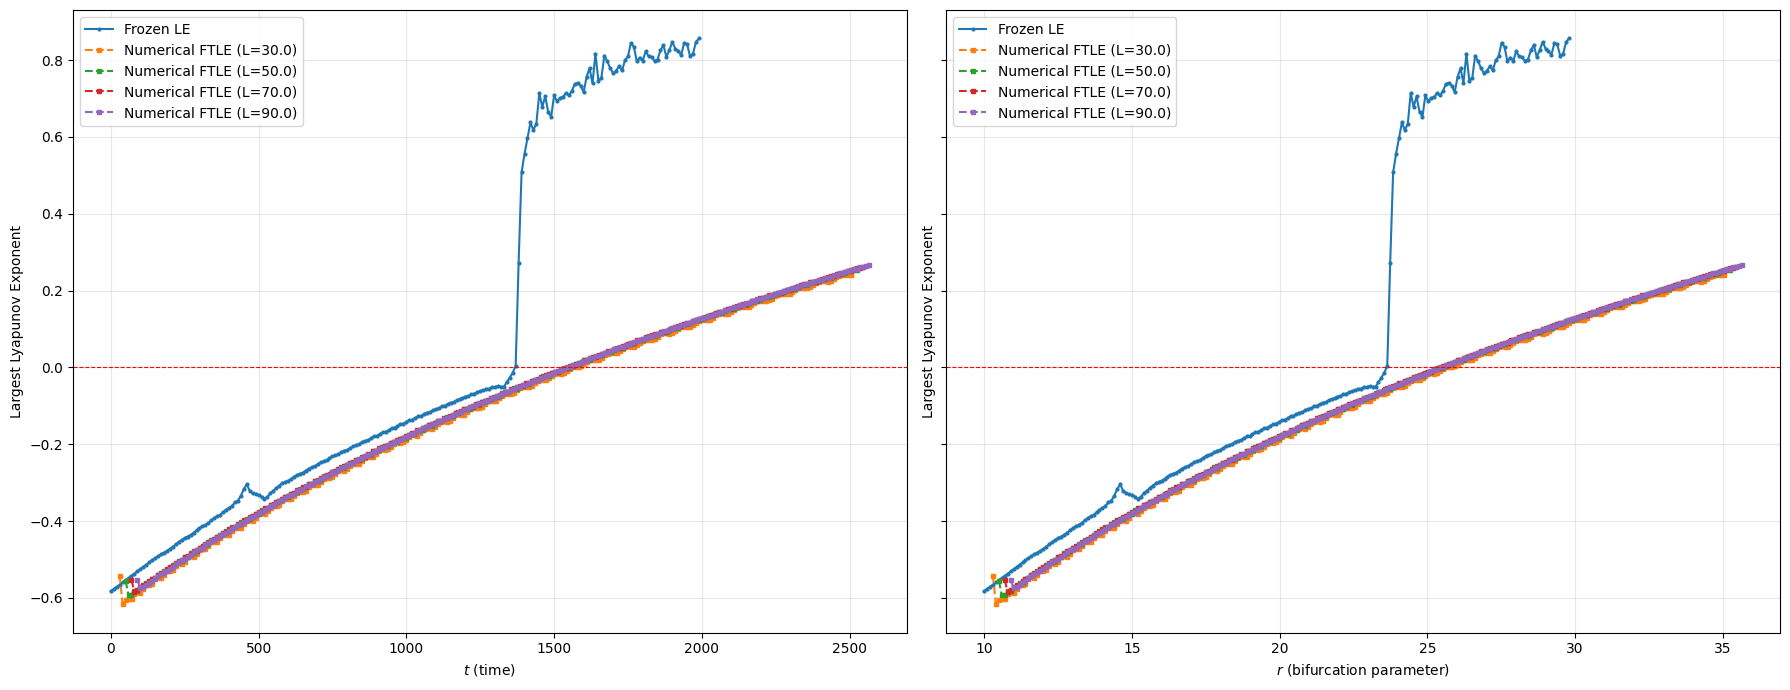

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)



# Left plot - FTLE vs time
axes[0].plot(t_func(frozen_init_tensor[:, 3].detach().cpu()), frozen_lle_tensor[:, 0].detach().cpu(), linestyle='-', marker='o', markersize=2, label='Frozen LE')


  # Shift r values by L*drdt to align with the correct time intervals
for i in range(lle_tensor.shape[0]):
    t_pts = t_func(r_pts+L_values[i].item()*drdt)
    axes[0].plot(
        t_pts,
        lle_tensor[i, :].detach().cpu(),
        linestyle='--',
        marker='s',
        markersize=3,
        label=f'Numerical FTLE (L={L_values[i].item()})'
    )



axes[0].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[0].set_ylabel('Largest Lyapunov Exponent')
axes[0].set_xlabel(r'$t$ (time)')
axes[0].grid(True, alpha=0.3)

axes[0].legend()

# Right plot - FTLE vs bifurcation parameter a
axes[1].plot(r_pts[:200], frozen_lle_tensor[:, 0].detach().cpu(), linestyle='-', marker='o', markersize=2, label='Frozen LE')

t_pts = t_func(r_pts)
for i in range(lle_tensor.shape[0]):
    axes[1].plot(
        r_pts + L_values[i].item()*drdt,  # Shift r values by L*drdt to align with the correct time intervals
        lle_tensor[i, :].detach().cpu(),
        linestyle='--',
        marker='s',
        markersize=3,
        label=f'Numerical FTLE (L={L_values[i].item()})'
    )

axes[1].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[1].set_ylabel('Largest Lyapunov Exponent')
axes[1].set_xlabel(r'$r$ (bifurcation parameter)')
axes[1].grid(True, alpha=0.3)

axes[1].legend()


plt.tight_layout()
plt.show()

# Compute Frozen system from FTLE formula

In [10]:
init_tensor =torch.load("data/10-03-26-lorenz_init_tensor.pt", map_location=device)


# Values of L 
L_values = torch.arange(0, 60, 10, dtype=torch.float32) 
dt_new = 0.01
print(f"\nComputing Lyapunov Exponents for {num_intervals} intervals for {L_values.shape[0]} "+
      f"different interval lengths and {init_tensor.shape[0]} values of a")
start_time = time.time()
temp_list = []
print(lorenz_analysis.model.f)
for i in range(0, L_values.shape[0] - 1):
    lle_lorenz = lorenz_analysis.lyapunov_spectrum(
        x0=init_tensor.unsqueeze(2),
        k=1,
        t0=0,
        dt=dt_new,
        num_pts_compute=int(L_values[i] / dt_new),
        t_transient_pts=0,
        non_autonomous=True
    )
    temp_list.append(lle_lorenz )
    print(f"  Interval {i+1}/{L_values.shape[0]}: {L_values[i].item()} time units")

lle_tensor = torch.stack(temp_list, dim=0)

NameError: name 'num_intervals' is not defined

In [ ]:
def eta(L):
    if L < 20: 
        raise ValueError("L too small. L must be >= 20")
    elif L > 250: 
        raise ValueError("L too large. L must be <= 250")


    lorenz = ds.Lorenz()
    lorenz.f = lorenz.na_f
    lorenz.drive_rate = 0.01
    lorenz_analysis = ds.DynamicalSystems_analysis(lorenz)

    t_span = (0.0, 2000.0)
    dt = 0.01

    traj = lorenz_analysis.model.solve(
        x0=torch.tensor([1, 1, 1, 10], dtype=torch.float32, device=device),
        t_span=t_span,
        dt=dt,
        driven=True
    )
    

    skip = 250 - L
    step = 10 # Compute LE starting at every 10 time units
    step_pts = int(step/dt)
    skip_pts = int(skip/dt)
    compute_pts = int(L/dt)

    print(f"Computing LE with L={L} (compute_pts={compute_pts})")

    #Skipping pts 
    num_step = int((traj.shape[0] - skip_pts) / step_pts)

    init = torch.stack([
        traj[skip_pts + i * step_pts, :]
        for i in range(num_step-1)
    ], dim=0)

    
    out = lorenz_analysis.lyapunov_spectrum(
            x0=init,
            k=1,
            t_span=(0, L), 
            dt=dt,
            t_transient=0,
            non_autonomous=True
        )
    
    r_out = init[:, 3] # Return r values for each initial condition (r(T-L)). Out is eta(L)
    return r_out, out

def deta_dL(L, epsilon=0.1):
    L = torch.tensor(L, requires_grad=False)  # Start with no gradient


    r_L, eta_L = eta(L)
    r_L_plus, eta_L_plus = eta(L + epsilon)

    out = (eta_L_plus - eta_L)/ epsilon

    return out 

In [43]:
L = 30
epsilon = 6
r_L, eta_L = eta(L)
r_L_plus, eta_L_plus = eta(L + epsilon)


deta_dL = (eta_L_plus - eta_L)/ epsilon



le_T_L = deta_dL*L + eta_L
r_delay = r_L


Computing LE with L=30 (compute_pts=3000)


Computing Lyapunov Spectrum: 100%|██████████| 3000/3000 [00:05<00:00, 572.21it/s]


Computing LE with L=36 (compute_pts=3600)


Computing Lyapunov Spectrum: 100%|██████████| 3600/3600 [00:06<00:00, 560.24it/s]


L = 30
r_delay, eta_pts = eta(L)
le_T_L = L*deta_dL(L, epsilon=1) + eta_pts

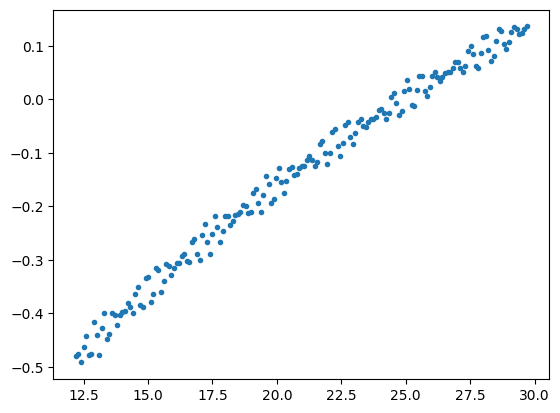

In [44]:
plt.plot(r_delay, le_T_L, linestyle='', marker='o', markersize = 3, label='Estimated Frozen LE (numerical)')

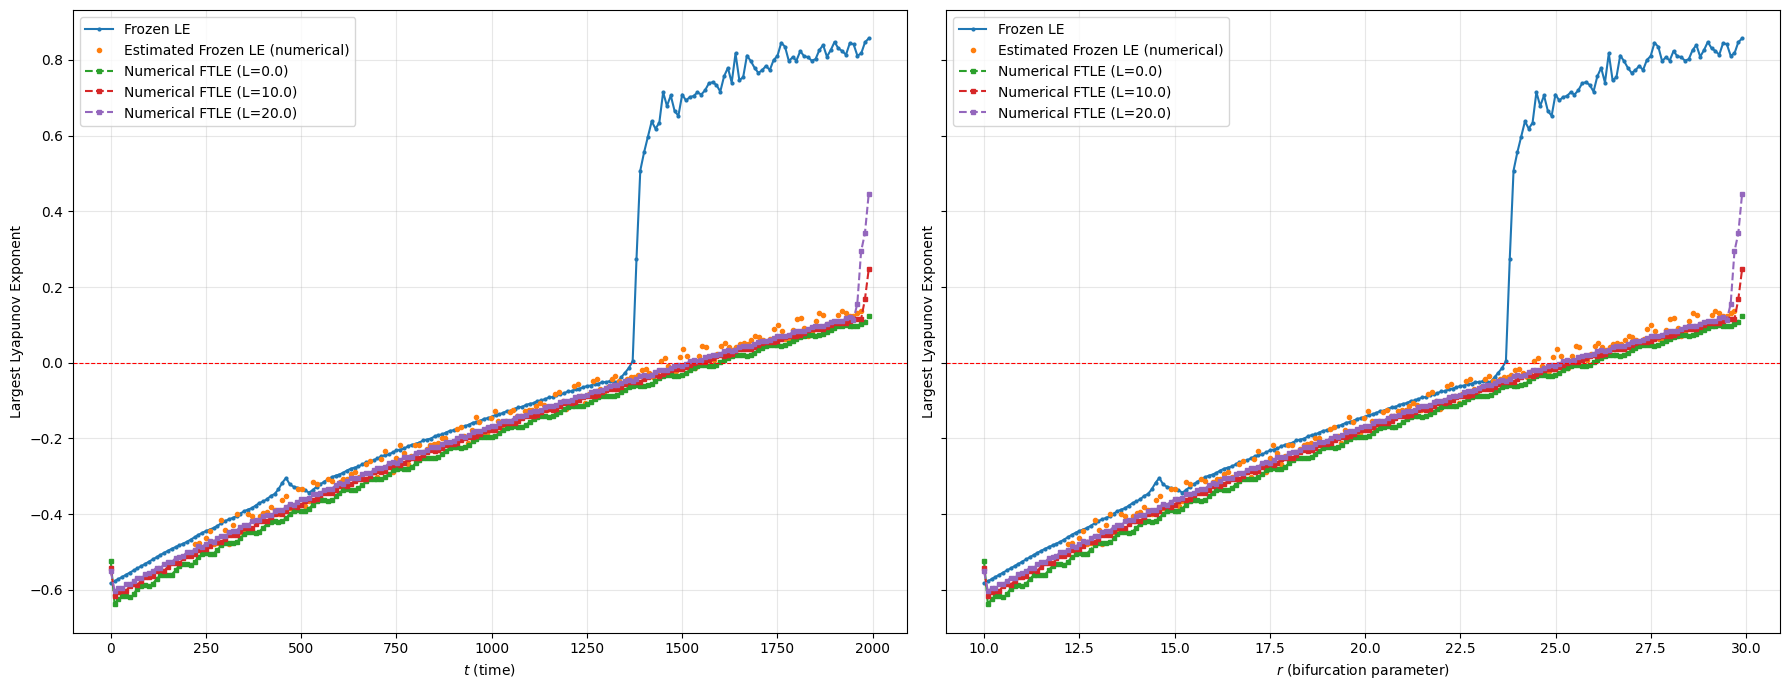

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

r_pts = init_tensor[:, 3].detach().cpu()

# Left plot - FTLE vs time
axes[0].plot(t_func(frozen_init_tensor[:, 3].detach().cpu()), frozen_lle_tensor[:, 0].detach().cpu(), linestyle='-', marker='o', markersize=2, label='Frozen LE')
axes[0].plot(t_func(r_delay), le_T_L, linestyle='', marker='o', markersize = 3, label='Estimated Frozen LE (numerical)')

t_pts = t_func(r_pts)
for i in range(lle_tensor.shape[0]):
    axes[0].plot(
        t_pts,
        lle_tensor[i, :].detach().cpu(),
        linestyle='--',
        marker='s',
        markersize=3,
        label=f'Numerical FTLE (L={L_values[i].item()})'
    )



axes[0].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[0].set_ylabel('Largest Lyapunov Exponent')
axes[0].set_xlabel(r'$t$ (time)')
axes[0].grid(True, alpha=0.3)

axes[0].legend()

# Right plot - FTLE vs bifurcation parameter a
axes[1].plot(r_pts, frozen_lle_tensor[:, 0].detach().cpu(), linestyle='-', marker='o', markersize=2, label='Frozen LE')

axes[1].plot(r_delay, le_T_L, linestyle='', marker='o', markersize = 3, label='Estimated Frozen LE (numerical)')

t_pts = t_func(r_pts)
for i in range(lle_tensor.shape[0]):
    axes[1].plot(
        r_pts,
        lle_tensor[i, :].detach().cpu(),
        linestyle='--',
        marker='s',
        markersize=3,
        label=f'Numerical FTLE (L={L_values[i].item()})'
    )

axes[1].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[1].set_ylabel('Largest Lyapunov Exponent')
axes[1].set_xlabel(r'$r$ (bifurcation parameter)')
axes[1].grid(True, alpha=0.3)

axes[1].legend()


plt.tight_layout()
plt.show()

In [53]:
estimated_frozen_le.shape

torch.Size([48, 1])

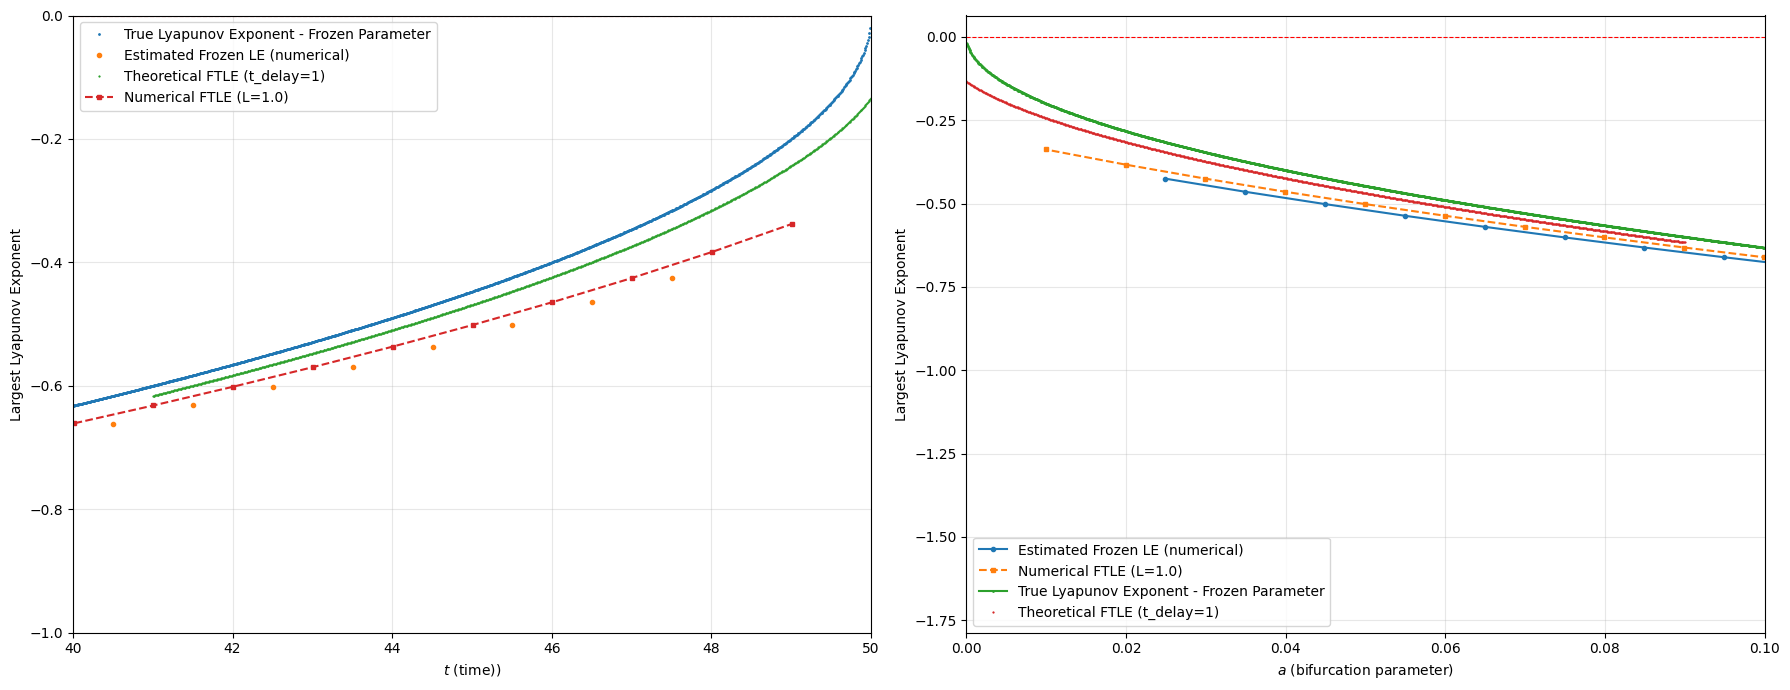

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left plot - Full view
# Left plot - Full view

t_pts = torch.arange(40.0, 50.0, 0.01)
axes[0].plot(t_pts, le_function(a_function(t_pts)), linestyle='', marker='o', markersize = 1, label='True Lyapunov Exponent - Frozen Parameter')
axes[0].plot(t_func(a_frozen_le), estimated_frozen_le, linestyle='', marker='o', markersize = 3, label='Estimated Frozen LE (numerical)')

for i in range(1, 2):
    t_delay = i
    ma_ed_func_T = lambda T: av_frozen_le(T, t_delay=t_delay)
    t_pts_delay = t_pts + t_delay
    axes[0].plot(t_pts_delay, ma_ed_func_T(t_pts_delay), linestyle='', marker='s', markersize = 0.6, label=f'Theoretical FTLE (t_delay={t_delay})')


# Left plot - FTLE vs time

t_pts = t_func(a_pts)
for i in range(lle_tensor.shape[0]-2):
    axes[0].plot(
        t_pts,
        lle_tensor[i, :].detach().cpu(),
        linestyle='--',
        marker='s',
        markersize=3,
        label=f'Numerical FTLE (L={L_values[i].item()})'
    )

axes[0].set_xlim(40.0, 50.0)
axes[0].set_ylim(-1, 0)

axes[0].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[0].set_ylabel('Largest Lyapunov Exponent')
axes[0].set_xlabel(r'$t$ (time))')
axes[0].grid(True, alpha=0.3)
axes[0].legend()







# Right plot - Full view
axes[1].plot(a_frozen_le, estimated_frozen_le, linestyle='-', marker='o', markersize = 3, label='Estimated Frozen LE (numerical)')

#Numerical FTLE vs a
t_pts = t_func(a_pts)
for i in range(lle_tensor.shape[0]-2):
    axes[1].plot(
        a_pts,
        lle_tensor[i, :].detach().cpu(),
        linestyle='--',
        marker='s',
        markersize=3,
        label=f'Numerical FTLE (L={L_values[i].item()})'
    )


# Theoretical FTLE vs a
t_pts = torch.arange(40.0, 50.0, 0.01)
axes[1].plot(a_function(t_pts), le_function(a_function(t_pts)), linestyle='-', marker='o', markersize = 1, label='True Lyapunov Exponent - Frozen Parameter')
for i in range(1, 2):
    t_delay = i
    ma_ed_func_T = lambda T: av_frozen_le(T, t_delay=t_delay)
    t_pts_delay = t_pts + t_delay
    axes[1].plot(a_function(t_pts_delay), ma_ed_func_T(t_pts_delay), linestyle='', marker='s', markersize = 0.6, label=f'Theoretical FTLE (t_delay={t_delay})')

axes[1].axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes[1].set_ylabel('Largest Lyapunov Exponent')
axes[1].set_xlabel(r'$a$ (bifurcation parameter)')
axes[1].set_xlim(0.0, 0.1)
#axes[1].set_ylim(-1, 0)

axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


In [46]:
list_le = []
list_a = []

In [47]:
L

1

for L in L_pts:
    a, b = eta(L)
    out = L*deta_dL(L) + a
    list_le.append(out)
    list_a.append(b)

In [359]:
L

tensor(2.5000)

In [360]:
L = 1
out = L*deta_dL(L) + eta(L)

Computing LE with L=1 (compute_pts=100)
Skipping 150 points to remove transient behavior
torch.Size([47, 2])


Computing Lyapunov Spectrum: 100%|██████████| 100/100 [00:00<00:00, 1264.33it/s]


Computing LE with L=1.0099999904632568 (compute_pts=101)
Skipping 149 points to remove transient behavior
torch.Size([47, 2])


Computing Lyapunov Spectrum: 100%|██████████| 101/101 [00:00<00:00, 1253.52it/s]


Computing LE with L=1 (compute_pts=100)
Skipping 150 points to remove transient behavior
torch.Size([47, 2])


Computing Lyapunov Spectrum: 100%|██████████| 100/100 [00:00<00:00, 1258.73it/s]


TypeError: unsupported operand type(s) for +: 'Tensor' and 'tuple'

In [148]:
t_pts = torch.arange(0, 50.0, 0.01)
a_pts = a_function(t_pts)

delay = 0.5 - a_function(L)

In [159]:
a_pts

tensor([5.0000e-01, 4.9990e-01, 4.9980e-01,  ..., 3.0005e-04, 2.0000e-04,
        1.0005e-04])

In [ ]:
init_tensor[:, 1]

tensor([0.5000, 0.4900, 0.4800, 0.4700, 0.4599, 0.4499, 0.4399, 0.4299, 0.4199,
        0.4099, 0.3999, 0.3899, 0.3799, 0.3699, 0.3599, 0.3499, 0.3399, 0.3299,
        0.3199, 0.3099, 0.2999, 0.2899, 0.2799, 0.2699, 0.2599, 0.2500, 0.2399,
        0.2299, 0.2199, 0.2099, 0.1999, 0.1899, 0.1799, 0.1699, 0.1599, 0.1499,
        0.1399, 0.1299, 0.1199, 0.1099, 0.0999, 0.0899, 0.0799, 0.0699, 0.0599,
        0.0499, 0.0399, 0.0299, 0.0199, 0.0099])

IndexError: list index out of range

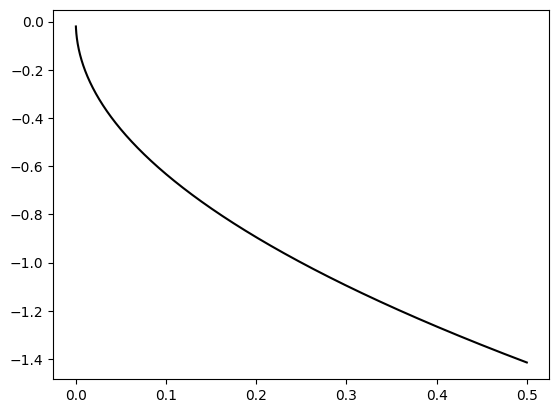

In [388]:
i = i + 1
plt.plot(a_pts, le_function(a_pts), label='True LE (Frozen)', color='k')
plt.plot(list_a[i], list_le[i], linestyle='', marker='+', color='r', markersize=4, label='Estimated True LE (Frozen)')
plt.xlabel('a (bifurcation parameter)')
plt.ylabel('Largest Lyapunov Exponent')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

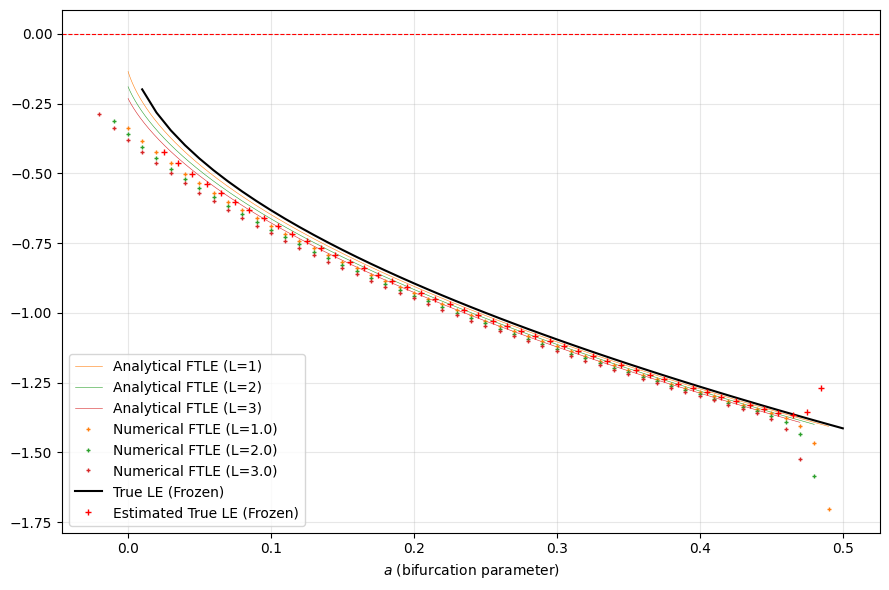

In [407]:
fig, axes = plt.subplots(1, 1, figsize=(9, 6), sharey=True)

# Build axes values from numerical tensors
a_pts = init_tensor[:, 1].detach().cpu()



dadt = -0.01 # From previous fill
t_func = lambda a: (a - 0.5)/dadt
t_pts = t_func(a_pts)

# Define color map for L values
colors = plt.cm.tab10(range(4))  # Use consistent colors for each L value


# Right panel: LE vs bifurcation parameter
# Analytical FTLE (lines)
for i in range(1, 4):
    t_delay_i = i
    t_pts_delay_i = torch.arange(t_delay_i, 50.0, 0.01)
    ma_vals = ma_ed_function(t_pts_delay_i, t_delay=t_delay_i)
    axes.plot(
        a_function(t_pts_delay_i),
        ma_vals,
        linestyle='-',
        linewidth=0.4,
        color=colors[i],
        label=f'Analytical FTLE (L={t_delay_i})'
    )

# Numerical FTLE (+ markers)
for i in range(lle_tensor.shape[0]):
    axes.plot(
        a_pts - 0.01 * L_values[i],
        lle_tensor[i, :].detach().cpu(),
        linestyle='',
        marker='+',
        markersize=3,
        color=colors[i+1],
        label=f'Numerical FTLE (L={L_values[i].item()})'
    )


axes.plot(a_pts, le_function(a_pts), label='True LE (Frozen)', color='k')
axes.plot(a_frozen_le, estimated_frozen_le, linestyle='', marker='+', color='r', markersize=4, label='Estimated True LE (Frozen)')





axes.axhline(y=0, color='r', linestyle='--', linewidth=0.8, alpha=1)
axes.set_xlabel(r'$a$ (bifurcation parameter)')
axes.grid(True, alpha=0.3)
axes.legend()

plt.tight_layout()
plt.show()